# Data Check — AI Supply Chain Network Advisor

Loads the saved reference data (parquet) and scenario history (SQLite) via `db.py` —
the same functions the Streamlit app uses, so this notebook always reflects
exactly what the app sees.

Run cells top to bottom. Re-run the "load" cells any time after regenerating data.

In [1]:
import sys
sys.path.insert(0, "..")  # run this notebook from the project root

import pandas as pd
import matplotlib.pyplot as plt

import db

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 1. Load reference (master) data

In [2]:
ref = db.load_reference_data()

for name, df in ref.items():
    print(f"{name:16s}  {len(df):>5} rows   cols: {list(df.columns)}")

inbound_cost        160 rows   cols: ['supplier_id', 'wh_id', 'distance_km', 'cost_per_pallet_eur', 'lead_time_days']
warehouses            8 rows   cols: ['wh_id', 'wh_name', 'city', 'lat', 'lon', 'regional_cost_index', 'capacity_pallets', 'fixed_cost_eur_per_month', 'handling_cost_eur_pallet']
suppliers            20 rows   cols: ['supplier_id', 'name', 'country', 'type', 'lat', 'lon', 'lead_time_days', 'volume_share']
demand             7200 rows   cols: ['store_id', 'group_id', 'demand_pallets']
delivery_baseline_share  14346 rows   cols: ['wh_id', 'store_id', 'group_id', 'volume_share']
product_groups       18 rows   cols: ['group_id', 'category', 'weight_kg_per_pallet', 'unit_value_eur_per_pallet']
supply_baseline_share    432 rows   cols: ['supplier_id', 'wh_id', 'group_id', 'volume_share']
delivery_cost      3200 rows   cols: ['wh_id', 'store_id', 'distance_km', 'cost_per_pallet_eur', 'days_to_serve']
stores              400 rows   cols: ['store_id', 'city', 'lat', 'lon']


## 2. Warehouses

In [3]:
warehouses = ref["warehouses"]
warehouses.sort_values("capacity_pallets", ascending=False)

,wh_id,wh_name,city,lat,lon,regional_cost_index,capacity_pallets,fixed_cost_eur_per_month,handling_cost_eur_pallet
1,WH002,Central WH Berlin,Berlin,52.5200,13.4050,1.00,33700,215400,11.14
2,WH003,Central WH Munich,Munich,48.1351,11.5820,1.35,32300,275300,14.81
0,WH001,Central WH Hamburg,Hamburg,53.5511,9.9937,1.15,18200,141600,12.91
3,WH004,Central WH Cologne,Cologne,50.9375,6.9603,1.10,11100,90400,12.62
4,WH005,Regional WH Frankfurt,Frankfurt,50.1109,8.6821,1.20,6300,68800,12.31
6,WH007,Regional WH Leipzig,Leipzig,51.3397,12.3731,0.80,6000,41100,9.08
5,WH006,Regional WH Stuttgart,Stuttgart,48.7758,9.1829,1.25,5900,67100,14.23
7,WH008,Regional WH Nuremberg,Nuremberg,49.4521,11.0767,0.90,5100,45000,8.50


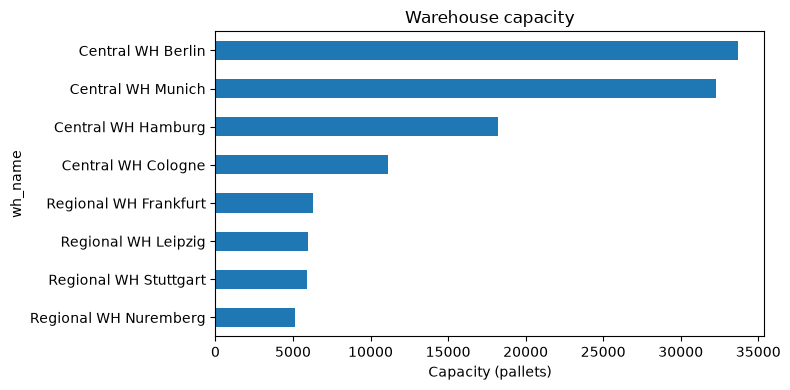

Max/min capacity ratio: 6.6x


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
warehouses.sort_values("capacity_pallets").plot.barh(x="wh_name", y="capacity_pallets", ax=ax, legend=False)
ax.set_xlabel("Capacity (pallets)")
ax.set_title("Warehouse capacity")
plt.tight_layout()
plt.show()

ratio = warehouses["capacity_pallets"].max() / warehouses["capacity_pallets"].min()
print(f"Max/min capacity ratio: {ratio:.1f}x")

## 3. Stores — geographic spread

In [5]:
stores = ref["stores"]
print(f"{len(stores)} stores across {stores['city'].nunique()} cities")
stores["city"].value_counts().head(15)

stores_by_city = stores["city"].value_counts()

400 stores across 83 cities


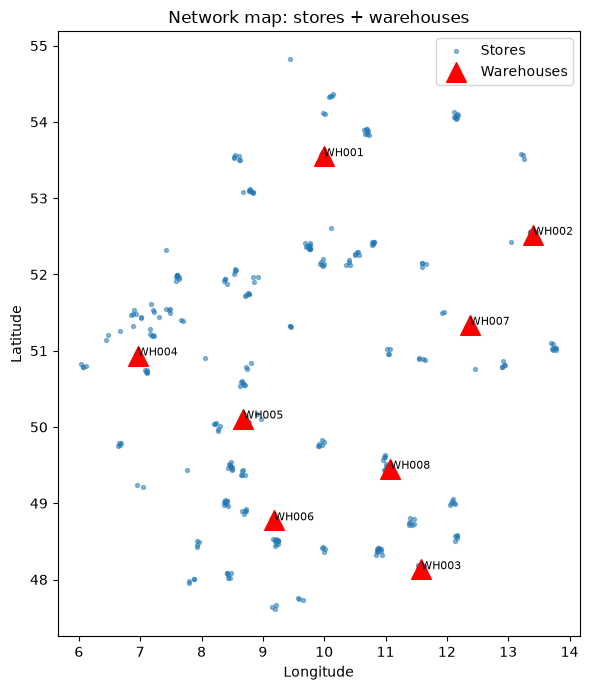

In [6]:
fig, ax = plt.subplots(figsize=(6, 7))
ax.scatter(stores["lon"], stores["lat"], s=8, alpha=0.5, label="Stores")
ax.scatter(warehouses["lon"], warehouses["lat"], s=200, marker="^", c="red", label="Warehouses")
for _, wh in warehouses.iterrows():
    ax.annotate(wh["wh_id"].replace("WH_", ""), (wh["lon"], wh["lat"]), fontsize=8, ha="left")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Network map: stores + warehouses")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Product groups

In [7]:
ref["product_groups"]

,group_id,category,weight_kg_per_pallet,unit_value_eur_per_pallet
0,PG01,Power & Hand Tools,350,9000
1,PG02,Fasteners & Fixings,600,3000
2,PG03,Plumbing & Fittings,450,4500
3,PG04,Electrical & Cabling,400,6000
4,PG05,Paint & Coatings,550,3500
5,PG06,Safety & Workwear,250,5000
6,PG07,Adhesives & Sealants,500,3200
7,PG08,Garden Equipment,400,7000
8,PG09,Timber & Boards,700,2800
9,PG10,Flooring Materials,650,3800


## 5. Demand

In [8]:
demand = ref["demand"]
print(f"Total demand: {demand['demand_pallets'].sum():,} units across {demand['store_id'].nunique()} stores")
demand.groupby("group_id")["demand_pallets"].sum().sort_values(ascending=False)

Total demand: 101,815 units across 400 stores


group_id
PG14    6019
PG10    5814
PG13    5812
PG04    5774
PG15    5765
PG01    5733
PG02    5712
PG08    5684
PG16    5679
PG06    5614
PG05    5610
PG03    5598
PG07    5589
PG11    5556
PG09    5539
PG17    5518
PG18    5437
PG12    5362
Name: demand_pallets, dtype: int64

## 6. Suppliers — domestic vs international split

In [9]:
suppliers = ref["suppliers"]
display(suppliers)

summary = suppliers.groupby("type").agg(
    count=("supplier_id", "count"),
    volume_share=("volume_share", "sum"),
    avg_lead_time_days=("lead_time_days", "mean"),
)
summary["count_share"] = summary["count"] / summary["count"].sum()
summary

,supplier_id,name,country,type,lat,lon,lead_time_days,volume_share
0,SUP_001,Shanghai Hardware & Tools 1,China,international,31.2304,121.4737,37,0.0384
1,SUP_002,Shenzhen Power Tools 2,China,international,22.5431,114.0579,39,0.2838
2,SUP_003,Warsaw Building Materials 3,Poland,international,52.2297,21.0122,28,0.0572
3,SUP_004,Milan Fixtures & Design 4,Italy,international,45.4642,9.1900,38,0.1854
4,SUP_005,Istanbul Workwear & Textiles 5,Turkey,international,41.0082,28.9784,28,0.0096
5,SUP_006,Rotterdam Import Hub 6,Netherlands,international,51.9244,4.4777,27,0.0256
6,SUP_007,Dortmund Supplier,Germany,domestic,51.5136,7.4653,2,0.0339
7,SUP_008,Bielefeld Supplier,Germany,domestic,52.0302,8.5325,4,0.0168
8,SUP_009,Chemnitz Supplier,Germany,domestic,50.8278,12.9214,5,0.0125
9,SUP_010,Augsburg Supplier,Germany,domestic,48.3705,10.8978,4,0.0187


,count,volume_share,avg_lead_time_days,count_share
type,,,,
domestic,14,0.3999,3.785714,0.7
international,6,0.6000,32.833333,0.3


## 7. Supply share (Supplier → product group)

In [ ]:
# ref["supply_share"].sort_values(["group_id", "share"], ascending=[True, False]).head(20)

KeyError: 'supply_share'

## 8. Cost curves — sanity check ranges

In [ ]:
print("Inbound cost (Supplier -> WH), EUR/unit:")
display(ref["inbound_cost"]["cost_per_pallet_eur"].describe())

print("\nDelivery cost (WH -> Store), EUR/unit:")
display(ref["delivery_cost"]["cost_per_pallet_eur"].describe())

## 9. Scenario history

Empty until you've run scenarios through the solver and saved them with `db.save_scenario(...)`.

In [ ]:
scenarios = db.list_scenarios()
scenarios

In [ ]:
# Inspect one scenario in detail — replace with a real scenario_id from the table above
# example:
# record = db.load_scenario("032a5d79")
# record["scenario_patch"], record["flows"].head()